# <a id='toc1_'></a>[Solving ODEs using Laplace Transforms](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Solving ODEs using Laplace Transforms](#toc1_)    
- [Example second order system](#toc2_)    
  - [Simulate response](#toc2_1_)    
  - [Add zero with location determined by "a"](#toc2_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
%reload_ext autoreload
%autoreload 2 

In [2]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root / "16_06_Class"))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

print("Basic Material version:", bm.__version__)
print("Control Materials version:", cm.__version__)

bm.setup_environment()
cm.setup_environment()

Basic Material version: 16.06-0.5
Control Materials version: 16.06-0.5
Running Python: 3.12.12
Running SymPy: 1.13.3


In [3]:
import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from sympy import symbols, Function, Eq, solve, init_printing, Heaviside, Symbol
from sympy import factor, expand

from sympy.integrals.transforms import laplace_transform
from sympy.integrals.transforms import inverse_laplace_transform
from sympy.abc import t, s, X 
init_printing(use_unicode=True)

a, x, g, X, G, tau = symbols('a x g X G tau', cls = Function)

t0p = 0+np.finfo(float).eps

# <a id='toc2_'></a>[Example second order system](#toc0_)

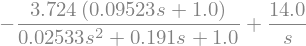

In [4]:
zz = 0.6 # damping
wn = 2*np.pi # freq

# input
W = laplace_transform(Heaviside(t,0), t, s, noconds = True)

# equations of motion (LT of ODE)
eom  = Eq(X(s)*(s**2+2*zz*wn*s+wn**2), 14*wn**2*(-0.075*s+1)*W)
eom.replace(Heaviside(0), 0)

# solve for X(s)
Xofs = solve(eom,X(s))[0]
# partional fraction print out
Xofs.apart().evalf(4)

In [5]:
inverse_laplace_transform(Xofs.apart(), s, t).simplify().evalf(3)
x_soln = inverse_laplace_transform(Xofs.apart(), s, t)
x_soln = factor(expand(x_soln))
cm.round_constants(x_soln, 3)

## <a id='toc2_1_'></a>[Simulate response](#toc0_)

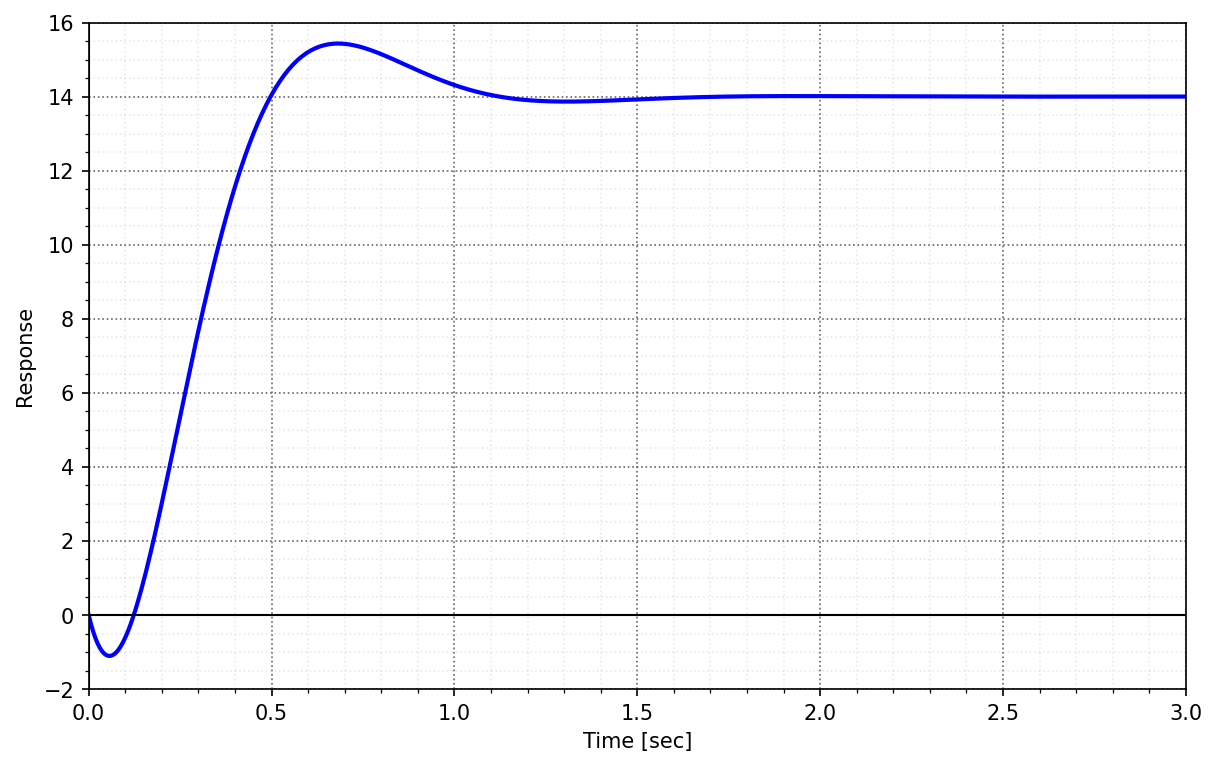

In [6]:
Tf = 3
tt = np.linspace(0,Tf,500)
y = lambda tt: [x_soln.subs(t,x) for x in tt]

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(tt,y(tt),color='b',lw=2)
plt.xlim(0,Tf)
plt.ylim(-2,16)
plt.xlabel('Time [sec]')
plt.ylabel('Response')
plt.savefig('figs/NMP_step_response.png',dpi=300)
bm.nicegrid(ax,7)
plt.show()

## <a id='toc2_2_'></a>[Add zero with location determined by "a"](#toc0_)

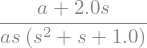

In [7]:
a = Symbol('a')
wn = 1
zz = 0.5

Gs  = Eq(X(s)*s*(s**2+2*zz*wn*s+wn**2), (s*wn/(a*zz)+wn**2))
Gs.replace(Heaviside(0), 0)
Xofs = solve(Gs,X(s))[0]
Xofs

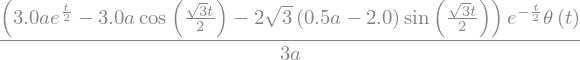

In [8]:
x_soln = inverse_laplace_transform(Xofs,s,t)
x_soln.simplify()

In [9]:
# ---- PUBLISH NOTEBOOK (instructor only) ----
import sys
import subprocess
from pathlib import Path
from IPython import get_ipython

# get current notebook path (VS Code)
ip = get_ipython()
nb_path = Path(ip.user_ns.get("__vsc_ipynb_file__", "")).resolve()

if not nb_path.exists():
    raise RuntimeError(
        "Could not determine notebook filename. "
        "This publish cell must be run from VS Code."
    )
    
# locate publish script (adjust if needed)
publish_script = Path.cwd() / "publish_notebook.py"
if not publish_script.exists():
    raise FileNotFoundError(publish_script)

# run publisher with SAME Python as kernel
result = subprocess.run(
    [sys.executable, str(publish_script), str(nb_path)],
    capture_output=True,
    text=True,
)

# surface real errors if any
if result.returncode != 0:
    print("STDOUT:\n", result.stdout)
    print("STDERR:\n", result.stderr)
    raise RuntimeError("publish_notebook.py failed")

print(f"Published → {nb_path.name}")

Published → 16_06_T2_Laplace.ipynb
